In [1]:
import numpy as np
import torch
import pandas as pd

import torch.nn as nn
import torch.optim as optim

from pmbrl.model import *
from pmbrl.data import *


In [2]:
params = {
    "mode": "all",
    "n":100,
    "num_epochs": 5000,
    "learning_rate": 0.001
}

norm = {
    "min_par_1": -0.21,
    "max_par_1": 0.21,
    "min_par_2": -1.82414,
    "max_par_2": 1.82414,
}

In [3]:
hist_s, hist_a, hist_p = generate_hist(n=params['n'])

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


# All

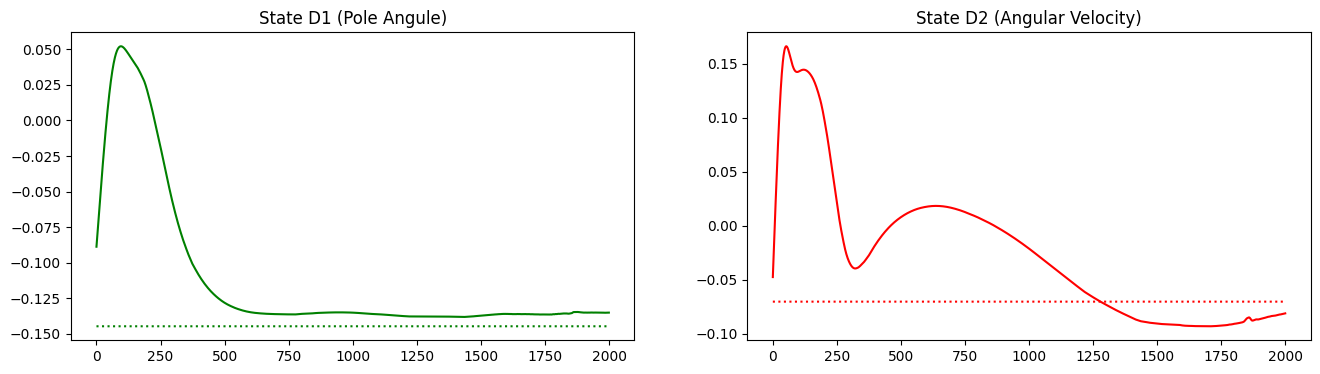

In [4]:
import matplotlib.pyplot as plt
import numpy as np


params = {
    "mode": "all",
    "n":100,
    "num_epochs": 2000,
    "learning_rate": 0.001
}

X_train, y_train, _, _ = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'], p=0)
m = Model(learning_rate=params['learning_rate'])
def iterate():
    m.train(X_train[:-1], y_train[:-1], num_epochs=1, debug=False, mode=params['mode'])
    return m.predict(X_train[-1:], mode=params['mode'])


lines = np.array([iterate() for epoch in range(params['num_epochs'])])
reff = np.array([y_train[-1:] for epoch in range(params['num_epochs'])])


fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(lines[:,:,0], color = 'g')
axs[0].plot(reff[:,:,0], linestyle = 'dotted', color = 'g')
axs[0].set_title('State D1 (Pole Angule)')
# axs[0].legend()

axs[1].plot(lines[:,:,1], color = 'r')
axs[1].plot(reff[:,:,1], linestyle = 'dotted', color = 'r')
axs[1].set_title('State D2 (Angular Velocity)')

plt.show()

# No Param 

In [5]:
class NeuralNet2(nn.Module):
    def __init__(self, s,a, hidden_size, output):
        super(NeuralNet2, self).__init__()
        self.input_set = sum([s,a,s,a])

        self.l1 = nn.Linear(self.input_set, hidden_size)
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.l3 = nn.Linear(hidden_size, output)
        self.relu = nn.ReLU()
        self.than = nn.Tanh()

    def forward(self, x, mode='all'):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        out = self.than(out)
        out = self.l3(out)
        return out

class Model2():
    def __init__(self,
                input_size = (2, 1), # 2d for s and s_, 1d for a and a_
                hidden_size = 10,
                output = 2, #2d for s_
                learning_rate = 0.001,
                criterion_clss = nn.MSELoss,
                optimizer_clss = optim.Adam
            ) -> None:
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output = output
        self.learning_rate = learning_rate

        self.estimator = NeuralNet2(*input_size, hidden_size, output)
        
        self.criterion = criterion_clss()
        self.optimizer = optimizer_clss(self.estimator.parameters(), lr=learning_rate)

    def train(self, X_train, y_train, num_epochs=100, debug=False, mode='all'):
        for epoch in range(num_epochs):
            outputs = self.estimator(X_train, mode)
            loss = self.criterion(outputs, y_train)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()  

            if debug and (epoch+1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')  

    def predict(self, x, mode='all'):
        value = None
        with torch.no_grad():
            value = self.estimator(x, mode)
        return value
    
m = Model()
X_train, y_train, X_test, y_test = train_test_split(hist_s, hist_a, hist_p, mode='all', p=.3)
m.train(X_train, y_train, num_epochs=5000, debug=False)
print('RMSE: ', torch.mean((m.predict(X_test) - y_test)**2, axis=0)**.5)

RMSE:  tensor([0.0413, 0.4603])


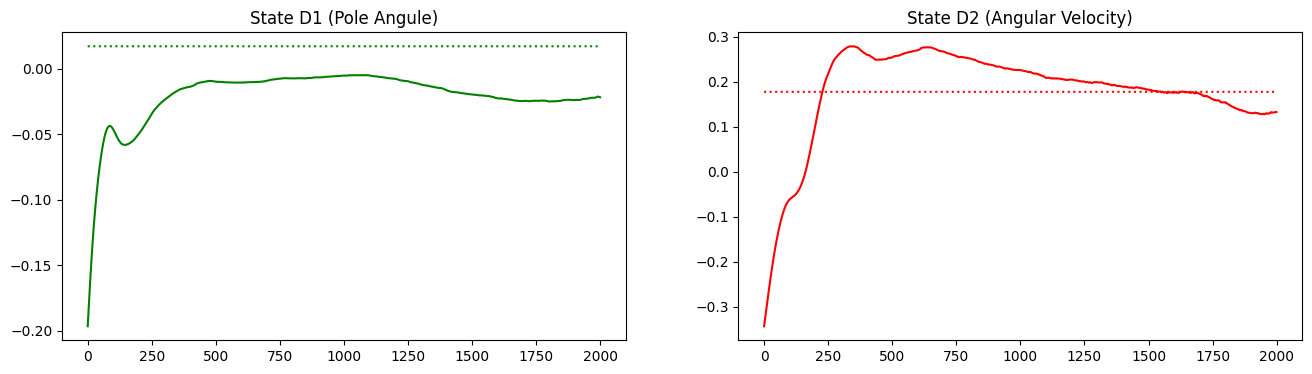

In [6]:
import matplotlib.pyplot as plt
import numpy as np


params = {
    "mode": "all",
    "n":100,
    "num_epochs": 2000,
    "learning_rate": 0.001
}

X_train, y_train, _, _ = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'], p=0)
m = Model2(learning_rate=params['learning_rate'])
def iterate():
    m.train(X_train[:-1], y_train[:-1], num_epochs=1, debug=False, mode=params['mode'])
    return m.predict(X_train[-1:], mode=params['mode'])


lines = np.array([iterate() for epoch in range(params['num_epochs'])])
reff = np.array([y_train[-1:] for epoch in range(params['num_epochs'])])


fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(lines[:,:,0], color = 'g')
axs[0].plot(reff[:,:,0], linestyle = 'dotted', color = 'g')
axs[0].set_title('State D1 (Pole Angule)')
# axs[0].legend()

axs[1].plot(lines[:,:,1], color = 'r')
axs[1].plot(reff[:,:,1], linestyle = 'dotted', color = 'r')
axs[1].set_title('State D2 (Angular Velocity)')

plt.show()

# TESTE

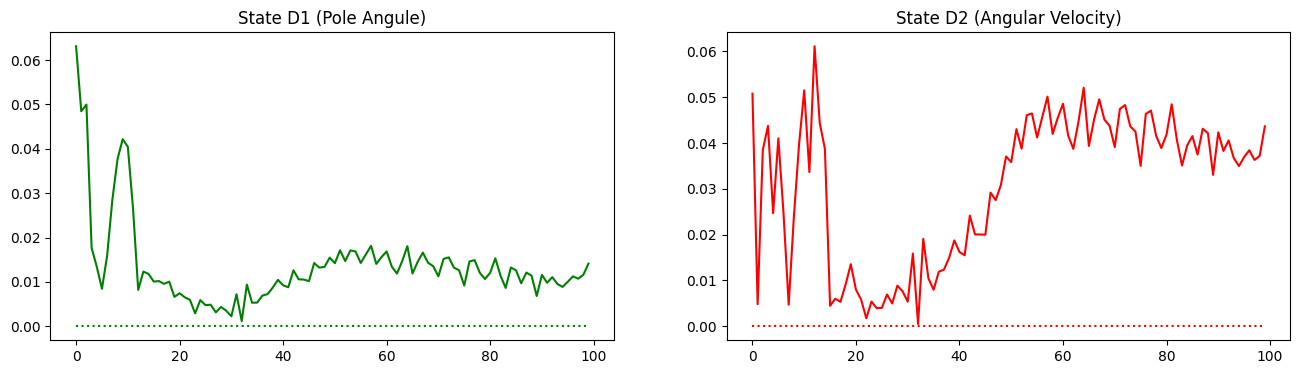

In [11]:
import matplotlib.pyplot as plt
import numpy as np


params = {
    "mode": "all",
    "n":1000,
    "m":100,
    "num_epochs": 1000,
    "learning_rate": 0.001
}

hist_s, hist_a, hist_p = generate_hist(n=params['n'], m=params['m'])
X_train, y_train, _, _ = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'], p=0)
m = Model(learning_rate=params['learning_rate'])

def iterate():
    m.train(X_train[:-1], y_train[:-1], num_epochs=params['num_epochs'], debug=False, mode=params['mode'])
    pred = m.predict(X_train[-1:], mode=params['mode'])
    return torch.mean((pred - y_train[-1:])**2, axis=0)**.5


lines = np.array([iterate() for _ in range(params['m'])])
reff = np.array([0 for _ in range(params['m'])])


fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(lines[:,0], color = 'g')
axs[0].plot(reff[:], linestyle = 'dotted', color = 'g')
axs[0].set_title('State D1 (Pole Angule)')
# axs[0].legend()

axs[1].plot(lines[:,1], color = 'r')
axs[1].plot(reff[:], linestyle = 'dotted', color = 'r')
axs[1].set_title('State D2 (Angular Velocity)')

plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np


params = {
    "mode": "all",
    "n":1000,
    "m":100,
    "num_epochs": 1000,
    "learning_rate": 0.001
}

hist_s, hist_a, hist_p = generate_hist(n=params['n'], m=params['m'])
X_train, y_train, _, _ = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'], p=0)
m = Model2(learning_rate=params['learning_rate'])

def iterate():
    m.train(X_train[:-1], y_train[:-1], num_epochs=params['num_epochs'], debug=False, mode=params['mode'])
    pred = m.predict(X_train[-1:], mode=params['mode'])
    return torch.mean((pred - y_train[-1:])**2, axis=0)**.5


lines = np.array([iterate() for _ in range(params['m'])])
reff = np.array([0 for _ in range(params['m'])])


fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(lines[:,0], color = 'g')
axs[0].plot(reff[:], linestyle = 'dotted', color = 'g')
axs[0].set_title('State D1 (Pole Angule)')
# axs[0].legend()

axs[1].plot(lines[:,1], color = 'r')
axs[1].plot(reff[:], linestyle = 'dotted', color = 'r')
axs[1].set_title('State D2 (Angular Velocity)')

plt.show()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


NameError: name 'Model2' is not defined